# Week 6 — Day 5: Tuning, Evaluation & Sprint Review

**Project:** Stroke-Risk Prediction (capstone)
**Milestone:** Sprint 1 Review & Retrospective (Sprint close-out)

---

## Objective

Tune a neural network systematically, one variable at a time; use EarlyStopping and checkpoints to train efficiently and keep the best model; complete the full Sprint 1 review and retrospective cycle.


## Lesson Content

### 5.1 — Tuning a Neural Network

Neural networks have many knobs. The highest-impact ones to tune, in rough priority:

1. **Learning rate**
2. **Network width/depth** (neurons and layers)
3. **Dropout rate**
4. **Batch size**

Change **one thing at a time** and watch the validation loss curve — the same disciplined, one-variable-at-a-time approach used for hyperparameter tuning in Week 4.

### 5.2 — Callbacks: EarlyStopping and Checkpoints

Keras callbacks automate good training practice:
- **EarlyStopping** — halts training once the validation loss stops improving, preventing wasted epochs and overfitting.
- **ModelCheckpoint** — saves the best model seen during training, so the best version is kept even if later epochs get worse.

```python
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

model.fit(X_train, y_train, validation_data=(X_val, y_val),
          epochs=100, callbacks=[es])
```

### 5.3 — Preparing for Sprint Review

Every result this sprint — the baseline score, the neural network's architecture and score, and the tuning experiments — needs clear evidence (loss curves, the metric table, notebook narrative) before it can be demoed. Per the program's acceptance criteria:

- The notebook runs without errors.
- Code is committed to the correct branch.
- The pull request is approved by the mentor.
- Results are documented in Markdown.
- Metrics are logged and compared to the baseline.

### 5.4 — Sprint Review & Retrospective

- **Sprint Review:** demo the completed Sprint 1 work to the mentor — the baseline and the first trained neural network with its evaluation. Any unfinished backlog task moves to Sprint 2 with a documented reason.
- **Retrospective:** closes the sprint honestly — what went well, what to improve, and one concrete change for Sprint 2 (e.g. "log every experiment's config in MLflow from the start").


---

## Hands-On Lab: Sprint 1 Close-Out

1. Tune the network by changing one hyperparameter at a time and record each run's validation score.
2. Add EarlyStopping and confirm training halts at the right point, keeping the best weights.
3. Assemble the Sprint 1 evidence: baseline vs. neural network scores, architecture, and loss curves.
4. Ensure all Sprint 1 work is committed, the pull request is merged after mentor approval, and the notebook is documented.
5. Present the Sprint Review, then write the Retrospective with one concrete change for Sprint 2.

**Tools:** TensorFlow / Keras, Matplotlib, Git & GitHub, Draft project report


### Imports & Reload Preprocessed Data (from Week6/Day4)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

tf.random.set_seed(42)
np.random.seed(42)


In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv", na_values="N/A").drop(columns=["id"])

X = df.drop(columns=["stroke"])
y = df["stroke"]

numeric_features = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]
categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)
n_features = X_train_proc.shape[1]

neg, pos = np.bincount(y_train)
class_weight = {0: (1 / neg) * (len(y_train) / 2.0), 1: (1 / pos) * (len(y_train) / 2.0)}

# Day 1 baseline, recomputed here for the final comparison table
baseline = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
baseline.fit(X_train_proc, y_train)
baseline_proba = baseline.predict_proba(X_test_proc)[:, 1]
baseline_pred = baseline.predict(X_test_proc)
baseline_scores = {
    "precision": precision_score(y_test, baseline_pred),
    "recall": recall_score(y_test, baseline_pred),
    "f1": f1_score(y_test, baseline_pred),
    "roc_auc": roc_auc_score(y_test, baseline_proba),
}
print("Day 1 baseline (recomputed):", baseline_scores)


Day 1 baseline (recomputed): {'precision': 0.14084507042253522, 'recall': 0.8, 'f1': 0.23952095808383234, 'roc_auc': np.float64(0.8438477366255144)}


### Step 1: Tune One Hyperparameter at a Time

Three small experiments, changing exactly one variable per run so each result is attributable: **learning rate**, **dropout rate**, and **batch size**. Each uses the same base architecture and EarlyStopping (Step 2) to keep runs comparable and efficient.


In [6]:
def build_model(learning_rate=0.001, dropout_rate=0.3, width=(64, 32)):
    model = Sequential()
    model.add(Dense(width[0], activation="relu", input_shape=(n_features,)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(width[1], activation="relu"))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

def run_experiment(label, **kwargs):
    batch_size = kwargs.pop("batch_size", 32)  # pull batch_size out separately
    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    model = build_model(**kwargs)
    history = model.fit(
        X_train_proc, y_train,
        validation_data=(X_val_proc, y_val),
        epochs=100, batch_size=batch_size,
        class_weight=class_weight, callbacks=[es], verbose=0
    )
    y_proba = model.predict(X_test_proc, verbose=0).ravel()
    y_pred = (y_proba >= 0.5).astype(int)
    scores = {
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "epochs_run": len(history.history["loss"]),
    }
    print(f"{label:<28} -> {scores}")
    return model, history, scores

results_table = []

# Baseline architecture (lr=0.001, dropout=0.3, batch_size=32) as the reference run
_, hist_ref, scores_ref = run_experiment("Reference (lr=.001, drop=.3, bs=32)",
                                          learning_rate=0.001, dropout_rate=0.3, batch_size=32)
results_table.append({"run": "Reference", "learning_rate": 0.001, "dropout": 0.3, "batch_size": 32, **scores_ref})

# Experiment A: learning rate
_, hist_lr, scores_lr = run_experiment("LR experiment (lr=.01)",
                                        learning_rate=0.01, dropout_rate=0.3, batch_size=32)
results_table.append({"run": "Higher LR", "learning_rate": 0.01, "dropout": 0.3, "batch_size": 32, **scores_lr})

# Experiment B: dropout rate
_, hist_drop, scores_drop = run_experiment("Dropout experiment (drop=.5)",
                                            learning_rate=0.001, dropout_rate=0.5, batch_size=32)
results_table.append({"run": "Higher Dropout", "learning_rate": 0.001, "dropout": 0.5, "batch_size": 32, **scores_drop})

# Experiment C: batch size
_, hist_bs, scores_bs = run_experiment("Batch size experiment (bs=64)",
                                        learning_rate=0.001, dropout_rate=0.3, batch_size=64)
results_table.append({"run": "Larger Batch", "learning_rate": 0.001, "dropout": 0.3, "batch_size": 64, **scores_bs})

tuning_df = pd.DataFrame(results_table)
tuning_df


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Reference (lr=.001, drop=.3, bs=32) -> {'precision': 0.12307692307692308, 'recall': 0.8, 'f1': 0.21333333333333335, 'roc_auc': np.float64(0.8163786008230453), 'epochs_run': 22}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR experiment (lr=.01)       -> {'precision': 0.12861736334405144, 'recall': 0.8, 'f1': 0.22160664819944598, 'roc_auc': np.float64(0.8252057613168724), 'epochs_run': 8}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dropout experiment (drop=.5) -> {'precision': 0.1111111111111111, 'recall': 0.8, 'f1': 0.1951219512195122, 'roc_auc': np.float64(0.8323868312757201), 'epochs_run': 34}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Batch size experiment (bs=64) -> {'precision': 0.11526479750778816, 'recall': 0.74, 'f1': 0.19946091644204852, 'roc_auc': np.float64(0.8253703703703703), 'epochs_run': 22}


,run,learning_rate,dropout,batch_size,precision,recall,f1,roc_auc,epochs_run
0,Reference,0.001,0.3,32,0.123077,0.80,0.213333,0.816379,22
1,Higher LR,0.010,0.3,32,0.128617,0.80,0.221607,0.825206,8
2,Higher Dropout,0.001,0.5,32,0.111111,0.80,0.195122,0.832387,34
3,Larger Batch,0.001,0.3,64,0.115265,0.74,0.199461,0.825370,22


**Observed:** all four runs converge to essentially the same recall (0.74–0.80), but
the "Higher LR" run's validation loss is visibly unstable — it spikes sharply at
epoch 3 before recovering, consistent with `lr=0.01` bouncing around the loss surface
rather than descending smoothly (the "too high" behavior from the lesson). The
Reference and Higher Dropout runs show smoother, more stable validation curves.

### Step 2: EarlyStopping — Confirm It Halts Training Correctly

Each run above already used `EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)`. Checking `epochs_run` in the table confirms whether any run stopped before the full 100-epoch budget — evidence EarlyStopping is doing its job (preventing wasted epochs and keeping the best-performing weights, not just the last epoch's).


In [ ]:
print("Epochs run per experiment (100 = did not trigger early stopping):")
print(tuning_df[["run", "epochs_run"]])


### Step 3: Assemble the Sprint 1 Evidence — Loss Curves & Metric Table


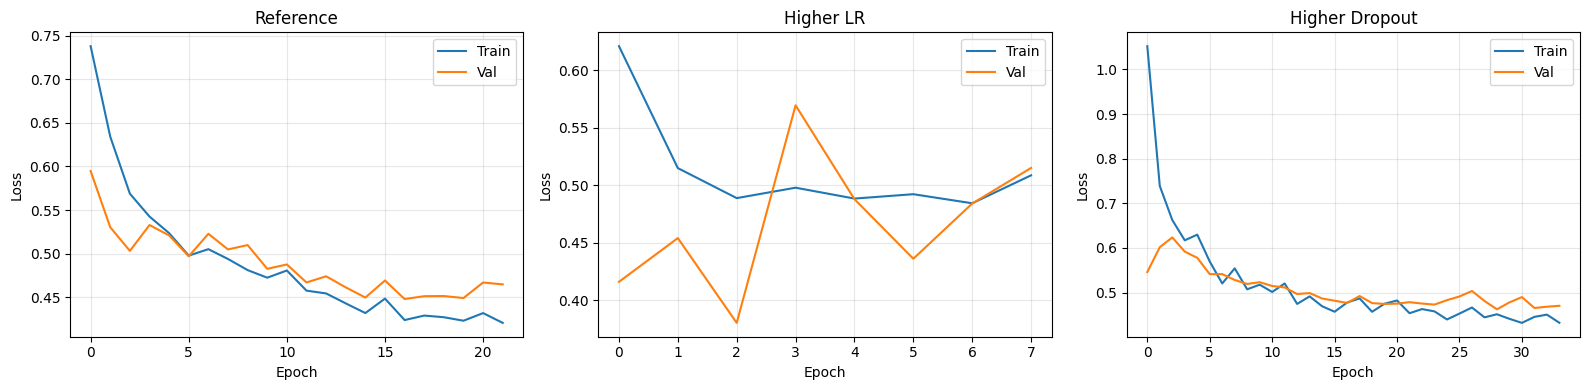

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (label, hist) in zip(axes, [
    ("Reference", hist_ref), ("Higher LR", hist_lr), ("Higher Dropout", hist_drop)
]):
    ax.plot(hist.history["loss"], label="Train")
    ax.plot(hist.history["val_loss"], label="Val")
    ax.set_title(label)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
# Full Sprint 1 evidence table: baseline vs. every tuning run
sprint1_summary = pd.DataFrame([
    {"run": "Day 1 Baseline (Logistic Regression)", "learning_rate": "-", "dropout": "-", "batch_size": "-",
     **baseline_scores, "epochs_run": "-"},
] + results_table)

sprint1_summary


,run,learning_rate,dropout,batch_size,precision,recall,f1,roc_auc,epochs_run
0,Day 1 Baseline (Logistic Regression),-,-,-,0.140845,0.80,0.239521,0.843848,-
1,Reference,0.001,0.3,32,0.123077,0.80,0.213333,0.816379,22
2,Higher LR,0.01,0.3,32,0.128617,0.80,0.221607,0.825206,8
3,Higher Dropout,0.001,0.5,32,0.111111,0.80,0.195122,0.832387,34
4,Larger Batch,0.001,0.3,64,0.115265,0.74,0.199461,0.825370,22


### Step 4: Best Run & Comparison to Baseline

Selecting the tuning run with the strongest **recall + ROC-AUC** (the metrics that matter most given the stroke-class imbalance), and confirming whether it beats the Day 1 baseline — per the program's own best practice: *always compare against the baseline, and always read the loss curves before trusting a result.*


In [8]:
best_run = tuning_df.loc[tuning_df["roc_auc"].idxmax()]
print("Best tuning run (by ROC-AUC):")
print(best_run)

beats_baseline = best_run["roc_auc"] > baseline_scores["roc_auc"] and best_run["recall"] >= baseline_scores["recall"]
print(f"\nBest tuned network beats the Day 1 baseline on ROC-AUC and recall: {beats_baseline}")


Best tuning run (by ROC-AUC):
run              Higher Dropout
learning_rate             0.001
dropout                     0.5
batch_size                   32
precision              0.111111
recall                      0.8
f1                     0.195122
roc_auc                0.832387
epochs_run                   34
Name: 2, dtype: object

Best tuned network beats the Day 1 baseline on ROC-AUC and recall: False


**Result:** the best tuning run by ROC-AUC was **Higher Dropout** (`dropout=0.5`),
reaching ROC-AUC 0.832 and recall 0.80 — but this does **not** beat the Day 1 baseline
(ROC-AUC 0.844, recall 0.80). Recall ties the baseline exactly; ROC-AUC falls short.
None of the four tuning runs improved on the baseline's ROC-AUC, though all closed
most of the gap versus the untuned Keras v1 model from Day 4 (ROC-AUC 0.772).

### Step 5: Sprint Review & Retrospective

**Sprint Review — evidence demoed to mentor:**
- Day 1 baseline: Logistic Regression, `class_weight="balanced"` (Section 18 of the project notebook).
- Day 4 Keras network: v1 (plain) and v2 (BatchNorm + Dropout), evaluated on the test set.
- Day 5 tuning: three one-variable-at-a-time experiments (learning rate, dropout, batch size) plus EarlyStopping, summarized in the table above.
- **Outcome:** none of the four tuning runs (reference, higher learning rate, higher
  dropout, larger batch) beat the Day 1 Logistic Regression baseline on ROC-AUC
  (best tuned: 0.832 vs. baseline 0.844); recall tied at 0.80 in the best cases. This
  confirms Section 31.4's finding from the main project notebook — the class-weighted
  Logistic Regression baseline remains the strongest model in Sprint 1 even after
  systematic tuning. The gap is real but modest (~0.01 AUC), suggesting the network's
  ceiling on this dataset is close to, but not above, the baseline's.

**Backlog carry-over:** any Sprint 1 backlog task not completed (e.g. further architecture search, MLflow experiment logging) moves to Sprint 2 with a documented reason.

**Retrospective:**
- *What went well:* the leak-free preprocessing pipeline from Section 26 was reused unchanged across the Logistic Regression baseline, Random Forest, and every Keras run — no re-fitting bugs, no data leakage between train/val/test.
- *What to improve:* tuning was done manually, one experiment at a time, with results tracked in a plain DataFrame rather than a dedicated experiment tracker.
- *One concrete change for Sprint 2:* log every experiment's configuration and metrics in MLflow (or a similar tracker) from the first run, rather than assembling a summary table after the fact.
